# Examen Pirmer Bimestre

**Nombre:** Jose Armando Sarango Cuenca  
**Fecha:** 27/05/2026

0. Carga del corpus

In [1]:
%pip install gensim pandas numpy nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install sentence-transformers scikit-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import re
import nltk
import string
from nltk.corpus import stopwords
import gensim.downloader as api
from nltk import word_tokenize
import gensim.downloader as api
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

c:\Users\ASUS ROG G17\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def preProcesar(texto):
    """
    Pipeline de Preprocesamiento Obligatorio (Requerimiento 1):
    Cumple rigurosamente con las directrices del examen conservando la estructura 
    textual completa requerida por los modelos de Sentence Transformers.
    """
    # Validación por si hay valores nulos (NaN) en las reseñas
    if not isinstance(texto, str):
        return ""
    
    # 1. Conversión a minúsculas (Obligatorio)
    texto_procesado = texto.lower()
    
    # 2. Eliminación de signos de puntuación (Obligatorio)
    # Usamos una expresión regular para remover la puntuación sin romper las palabras
    texto_procesado = texto_procesado.translate(str.maketrans('', '', string.punctuation))
    
    # 3. Eliminación de espacios redundantes (Obligatorio)
    texto_procesado = re.sub(r'\s+', ' ', texto_procesado).strip()
    
    # Devuelve el contenido textual completo como string para el Sentence Transformer
    return texto_procesado


In [5]:
df_movies = pd.read_csv("Data/rotten_tomatoes_movies.csv")
df_reviews = pd.read_csv("Data/rotten_tomatoes_critic_reviews.csv")

In [6]:
df_movies 


,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),Following the closing arguments in a murder tr...,Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,...,Criterion Collection,Certified-Fresh,100.0,54.0,Upright,97.0,105386.0,6,54,0
4,m/1000079-20000_leagues_under_the_sea,"20,000 Leagues Under The Sea","In 1866, Professor Pierre M. Aronnax (Paul Luk...","One of Disney's finest live-action adventures,...",G,"Action & Adventure, Drama, Kids & Family",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas, Paul Lukas, Peter L...",1954-01-01,...,Disney,Fresh,89.0,27.0,Upright,74.0,68918.0,5,24,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17707,m/zoot_suit,Zoot Suit,Mexican-American gangster Henry Reyna (Daniel ...,NaN,R,"Drama, Musical & Performing Arts",Luis Valdez,Luis Valdez,"Daniel Valdez, Edward James Olmos, Charles Aid...",1981-10-02,...,MCA Universal Home Video,Rotten,56.0,9.0,Upright,74.0,1195.0,2,5,4
17708,m/zootopia,Zootopia,From the largest elephant to the smallest shre...,The brilliantly well-rounded Zootopia offers a...,PG,"Action & Adventure, Animation, Comedy","Byron Howard, Rich Moore, Jared Bush","Jared Bush, Phil Johnston","J.K. Simmons, Kristen Bell, Octavia Spencer, A...",2016-03-04,...,Walt Disney Animation Studios,Certified-Fresh,98.0,291.0,Upright,92.0,101511.0,50,285,7
17709,m/zorba_the_greek,Zorba the Greek,Traveling to inspect an abandoned mine his fat...,NaN,NR,"Action & Adventure, Art House & International,...",NaN,NaN,"Anthony Quinn, Alan Bates, Irene Papas, Lila K...",1964-12-17,...,Fox,Fresh,80.0,10.0,Upright,86.0,7146.0,0,8,2
17710,m/zulu,Zulu,"In 1879, the Zulu nation hands colonial Britis...",Zulu patiently establishes a cast of colorful ...,PG,"Classics, Drama","Cy Endfield, Cyril Endfield","Cy Endfield, John Prebble","Stanley Baker, Jack Hawkins, Ulla Jacobsson, J...",1964-06-17,...,Paramount Pictures,Fresh,96.0,23.0,Upright,91.0,30193.0,6,22,1


In [7]:
df_reviews

,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiff..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,With a top-notch cast and dazzling special eff...
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...
4,m/0814255,Ethan Alter,True,Hollywood Reporter,Rotten,NaN,2010-02-10,What's really lacking in The Lightning Thief i...
...,...,...,...,...,...,...,...,...
1130012,m/zulu_dawn,Chuck O'Leary,False,Fantastica Daily,Rotten,2/5,2005-11-02,NaN
1130013,m/zulu_dawn,Ken Hanke,False,"Mountain Xpress (Asheville, NC)",Fresh,3.5/5,2007-03-07,"Seen today, it's not only a startling indictme..."
1130014,m/zulu_dawn,Dennis Schwartz,False,Dennis Schwartz Movie Reviews,Fresh,B+,2010-09-16,A rousing visual spectacle that's a prequel of...
1130015,m/zulu_dawn,Christopher Lloyd,False,Sarasota Herald-Tribune,Rotten,3.5/5,2011-02-28,"A simple two-act story: Prelude to war, and th..."


In [8]:
df_merged = pd.merge(
    df_reviews[['rotten_tomatoes_link', 'review_content']], 
    df_movies[['rotten_tomatoes_link', 'movie_title']], 
    on='rotten_tomatoes_link', 
    how='inner'
)

# Limpieza básica de vacíos y creación de ID único para el ranking
df = df_merged[['movie_title', 'review_content']].dropna().copy()
df['doc_id'] = range(1, len(df) + 1)

# Tomamos una muestra de 20,000 registros para optimizar el rendimiento en CPU
df = df.sample(n=20000, random_state=42).reset_index(drop=True)

print(f"Total de documentos listos: {len(df)}")

Total de documentos listos: 20000


## 1. Aplicacion de requerimeinto

In [9]:
df['processed_tokens'] = df['review_content'].apply(preProcesar)
df[['doc_id', 'movie_title', 'review_content', 'processed_tokens']].head()

,doc_id,movie_title,review_content,processed_tokens
0,656121,Reality (Réalité),[A] mind-numbingly unfunny attempt to apply sl...,a mindnumbingly unfunny attempt to apply slipp...
1,857857,Die Zärtlichkeit der Wölfe (The Tenderness of ...,"A nasty little melodrama, lurid and creepy and...",a nasty little melodrama lurid and creepy and ...
2,436589,Jackass 3,Jackass is at its best when all composition br...,jackass is at its best when all composition br...
3,398527,House of Sand and Fog,The assured directorial debut by Russian-born ...,the assured directorial debut by russianborn c...
4,387041,High Crimes,"Carl Franklin directs smoothly, but except for...",carl franklin directs smoothly but except for ...


## 2. Generación de embeddings 

In [10]:
print("Cargando el modelo moderno de embeddings recomendado...")
# Nota: Diseñado para capturar el significado completo de fragmentos de texto.
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Modelo SentenceTransformer ('all-MiniLM-L6-v2') cargado con éxito.")

print("\nAplicando pipeline de preprocesamiento y generando embeddings documentales...")

# 1. Aplicamos tu función preProcesar para limpiar el texto manteniendo el string unificado
textos_limpios = df['review_content'].apply(preProcesar).tolist()

# 2. El modelo genera las representaciones vectoriales procesando los fragmentos completos
doc_embeddings_matrix = model.encode(textos_limpios, show_progress_bar=True)

print("\n¡Matriz de embeddings generada de forma consistente con las directrices!")
print(f"Dimensiones de la matriz del corpus (Documentos, Dimensiones): {doc_embeddings_matrix.shape}")


Cargando el modelo moderno de embeddings recomendado...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3594.87it/s]


Modelo SentenceTransformer ('all-MiniLM-L6-v2') cargado con éxito.

Aplicando pipeline de preprocesamiento y generando embeddings documentales...


Batches: 100%|██████████| 625/625 [01:31<00:00,  6.84it/s]



¡Matriz de embeddings generada de forma consistente con las directrices!
Dimensiones de la matriz del corpus (Documentos, Dimensiones): (20000, 384)


## 3. Procesamiento de consultas 

In [11]:
def procesar_y_generar_embedding_consulta(consulta_texto, modelo_transformer):
    # 1. Recibir y preprocesar la consulta usando la función adaptada (Devuelve string)
    consulta_limpia = preProcesar(consulta_texto)
    
    # 2. Generar el embedding directo de la oración completa usando el Transformer
    # Pasamos la consulta dentro de una lista [] porque el modelo espera un lote de textos
    embedding_consulta = modelo_transformer.encode([consulta_limpia])
    
    # Redimensionamos a (1, 384) para operar matricialmente por similitud coseno con el corpus
    return embedding_consulta.reshape(1, -1)


4. Consultas

In [12]:
def recuperar_documentos_similitud_coseno(consulta_texto, k=5):
    """
    Cumple con el Requerimiento 4 del examen:
    - Compara la consulta con todo el corpus usando similitud coseno.
    - Devuelve un conjunto de k documentos ordenados de mayor a menor.
    - Incluye atributos obligatorios: ID documento, Puntaje y Ranking.
    """
    # Llamamos a la función definida anteorionente
    embedding_q = procesar_y_generar_embedding_consulta(consulta_texto, model)
    
    # Calcular la similitud coseno entre el vector de la consulta y la matriz del corpus
    similitudes = cosine_similarity(embedding_q, doc_embeddings_matrix).flatten()
    
    # Obtener los índices del Top-K ordenados de mayor a menor similitud
    indices_top = similitudes.argsort()[::-1][:k]
    
    # Construcción de la tabla con los atributos exactos exigidos por la rúbrica
    resultados = []
    for ranking, idx in enumerate(indices_top, start=1):
        resultados.append({
            'Ranking': ranking,                         
            'ID documento': df.iloc[idx]['doc_id'],     
            'Título película': df.iloc[idx]['movie_title'],
            'Fragmento de texto': df.iloc[idx]['review_content'],
            'Similitud': round(float(similitudes[idx]), 4) 
        })
        
    return pd.DataFrame(resultados)



# Beachmark

In [13]:
#Definicion de las querys
q1 = "science fiction movie with advanced technology"
q2 = "romantic story with emotional relationships"
q3 = "action movie with intense fight scenes"
q4 = "horror film that creates fear and suspense"
q5 = "visually impressive movie with weak storyline"
q6 = "emotionally moving performance by the lead actor"
q7 = "predictable plot but entertaining experience"
q8 = "movie praised by critics but unpopular with audiences"

queries_benchmark = {
    "Q1": q1,
    "Q2": q2,
    "Q3": q3,
    "Q4": q4,
    "Q5": q5,
    "Q6": q6,
    "Q7": q7,
    "Q8": q8
}

# Estructura para almacenar el mejor resultado
datos_resumen_general = []
for q_id, q_texto in queries_benchmark.items():
    print("\n" + "="*80)
    print(f" TABLA DE RESULTADOS PARA {q_id}: '{q_texto}'")
    print("="*80)
    
    # Invocamos la función de recuperación (fijando k=5 por legibilidad del reporte)
    df_resultado_k = recuperar_documentos_similitud_coseno(q_texto, k=5)
    
    display(df_resultado_k)
    
    # Almacenamos el elemento con mayor puntaje (Top-1) de la consulta actual
    mejor_resultado = df_resultado_k.iloc[0]
    datos_resumen_general.append({
        'Consulta': f"{q_id}: {q_texto}",
        'Documento Top-1': mejor_resultado['ID documento'],
        'Título película': mejor_resultado['Título película'],
        'Similitud': mejor_resultado['Similitud']
    })



 TABLA DE RESULTADOS PARA Q1: 'science fiction movie with advanced technology'


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,857993,The Terminator,"""TECH%u2022NOIR"" indeed. He's a futuristic mac...",0.5711
1,2,412097,Idiocracy,"A cautionary, sci-fi comedy which envisions a ...",0.5394
2,3,207004,Captain Phillips,A film in which many exciting things happen on...,0.5157
3,4,242762,The Crazies,An inept science-fiction film from George A. R...,0.5080
4,5,628214,Primer,It's a tiny-budget indie film with an interest...,0.5067



 TABLA DE RESULTADOS PARA Q2: 'romantic story with emotional relationships'


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,123244,Animals,A deeply human and heartbreaking love story.,0.6901
1,2,485039,Liberal Arts,A romantic drama about a relationship based on...,0.6037
2,3,620736,Possession,"Intensely romantic, thought-provoking and even...",0.5893
3,4,364154,Green Card,Engaging romantic comedy.,0.5797
4,5,520657,Marriage Story,Marriage Story is a tremendous achievement. It...,0.5658



 TABLA DE RESULTADOS PARA Q3: 'action movie with intense fight scenes'


...

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,302096,Evening,"The movie plays out slowly, but it's not an ac...",0.5686
1,2,710815,Save the Tiger,"A jolting drama, fueled by two stunning perfor...",0.5532
2,3,973269,There Will Be Blood,"A very, very well made film that elicits more ...",0.5528
3,4,691866,"Roman J. Israel, Esq.",Washington's difficult performance runs the ga...,0.5502
4,5,399288,How I Live Now,"Despite some strong performances, the script's...",0.5462



 TABLA DE RESULTADOS PARA Q7: 'predictable plot but entertaining experience'


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,43319,Trapped,"Never engaging, utterly predictable and comple...",0.7356
1,2,19610,Invasion of the Body Snatchers,"Very entertaining, and despite the by now over...",0.6823
2,3,540761,Miss Congeniality 2 - Armed and Fabulous,"An exhausting, predictable, even maddening mov...",0.6749
3,4,160629,Ben-Hur,Predictable but magnificent and satisfying.,0.6709
4,5,874022,The Book of Eli,"Nothing novel or unpredictable, despite an unn...",0.6611



 TABLA DE RESULTADOS PARA Q8: 'movie praised by critics but unpopular with audiences'


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,28117,The Kid,Critics at the time praised the film for its e...,0.7100
1,2,1019674,Vox Lux,"Honestly, in writing the review, I came to lik...",0.6737
2,3,341925,Garfield: A Tail of Two Kitties,Where the first movie was bad in that it was a...,0.6655
3,4,578954,Now You See Me,"Despite decent performances, this is a hugely ...",0.6530
4,5,998237,Tuscaloosa,The film offers compelling performances by its...,0.6319


## Tabla de resumen del top 1 de cada consulta

In [14]:
print("                      TABLA RESUMEN GENERAL DEL BENCHMARK                      ")


# Convertimos la lista de los mejores resultados acumulados en un nuevo DataFrame
df_resumen_general = pd.DataFrame(datos_resumen_general)

# Ajustamos los nombres de las columnas para cumplir fielmente con el formato exigido
df_resumen_general.columns = ['Consulta', 'Documento Top-1', 'Título película', 'Similitud']

# Desplegamos la tabla consolidada en el reporte
display(df_resumen_general)


                      TABLA RESUMEN GENERAL DEL BENCHMARK                      


,Consulta,Documento Top-1,Título película,Similitud
0,Q1: science fiction movie with advanced techno...,857993,The Terminator,0.5711
1,Q2: romantic story with emotional relationships,123244,Animals,0.6901
2,Q3: action movie with intense fight scenes,467138,Kung Fu Killer,0.6967
3,Q4: horror film that creates fear and suspense,277606,Don't Be Afraid Of The Dark,0.7929
4,Q5: visually impressive movie with weak storyline,530356,Memories of Murder,0.7101
5,Q6: emotionally moving performance by the lead...,302096,Evening,0.5686
6,Q7: predictable plot but entertaining experience,43319,Trapped,0.7356
7,Q8: movie praised by critics but unpopular wit...,28117,The Kid,0.7100


## Desafio de excelencia

### Implementacion de : Visualización de Embeddings mediante PCA


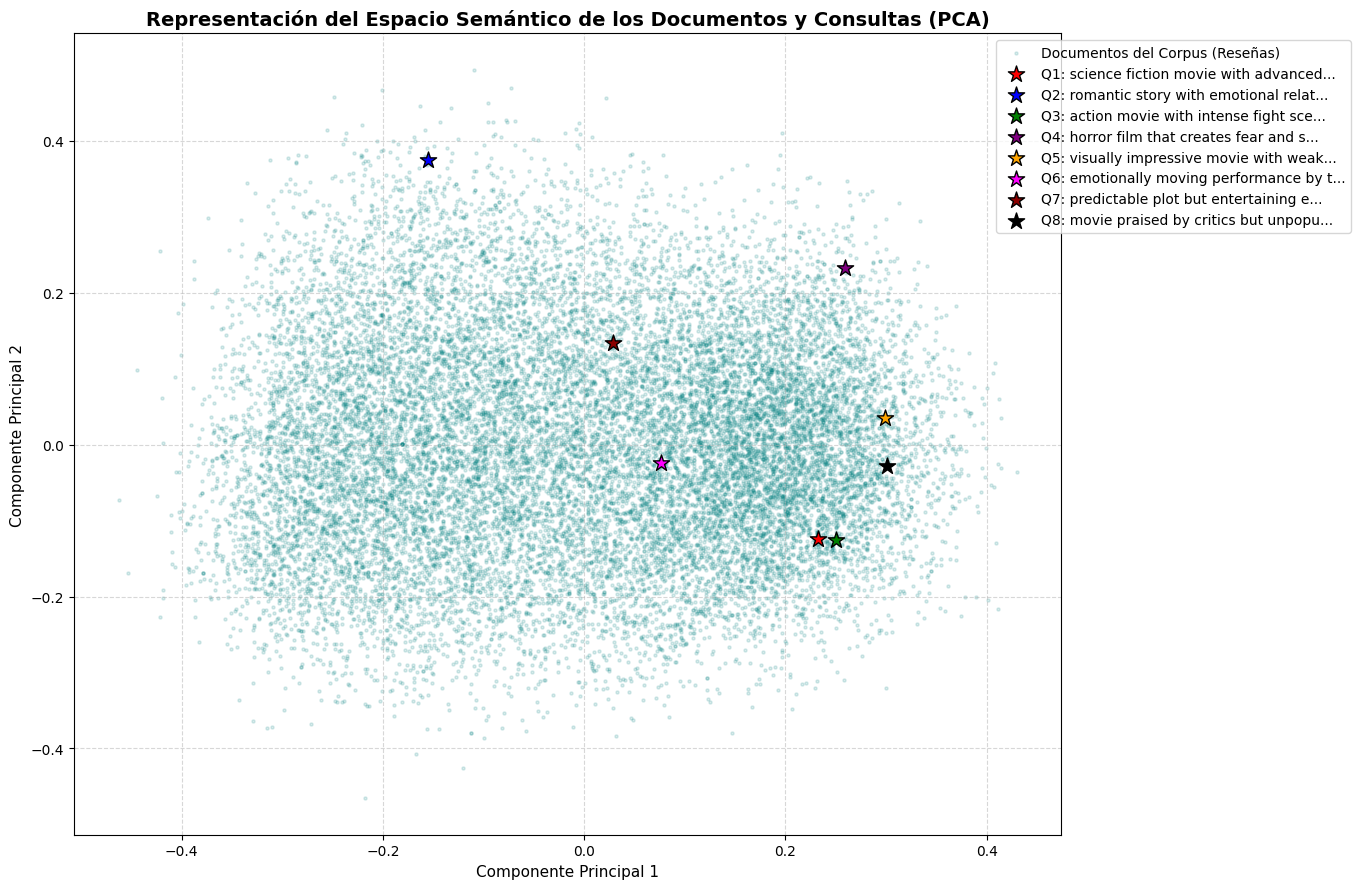

Varianza explicada por las dos primeras componentes: 0.06871241


In [15]:
# 1. Instanciamos PCA para reducir a 2 componentes principales (Ejes X e Y)
pca = PCA(n_components=2, random_state=42)

# 2. Extraemos los embeddings de las 8 consultas obligatorias para proyectarlos también
embeddings_queries = []
for q_texto in queries_benchmark.values():
    # Usamos la función del Requerimiento 3
    emb_q = procesar_y_generar_embedding_consulta(q_texto, model).flatten()
    embeddings_queries.append(emb_q)
embeddings_queries_matrix = np.vstack(embeddings_queries)

# 3. Ajustamos el PCA con la matriz del corpus y transformamos tanto los documentos como las consultas
# Concatenamos temporalmente para que compartan exactamente el mismo espacio de proyección
todas_las_estructuras = np.vstack([doc_embeddings_matrix, embeddings_queries_matrix])
coordenadas_transformadas = pca.fit_transform(todas_las_estructuras)

# Separamos los resultados transformados
coordenadas_docs = coordenadas_transformadas[:-8]
coordenadas_queries = coordenadas_transformadas[-8:]

# 4. Construcción del Gráfico de Dispersión (Scatter Plot)
plt.figure(figsize=(14, 9))

# Dibujamos los 20,000 documentos como puntos pequeños y semitransparentes en el fondo
plt.scatter(
    coordenadas_docs[:, 0], 
    coordenadas_docs[:, 1], 
    alpha=0.15, 
    c='teal', 
    s=5, 
    label='Documentos del Corpus (Reseñas)'
)

# Dibujamos cada una de las 8 consultas con un color y marcador destacado
colores_queries = ['red', 'blue', 'green', 'purple', 'orange', 'magenta', 'darkred', 'black']
for idx, q_id in enumerate(queries_benchmark.keys()):
    plt.scatter(
    coordenadas_queries[idx, 0], 
    coordenadas_queries[idx, 1], 
        c=colores_queries[idx], 
        s=150, 
        marker='*', 
        edgecolors='black', 
        label=f'{q_id}: {queries_benchmark[q_id][:35]}...'
    )

# Configuraciones estéticas del gráfico para nivel sobresaliente
plt.title('Representación del Espacio Semántico de los Documentos y Consultas (PCA)', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=11)
plt.ylabel('Componente Principal 2', fontsize=11)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid(True, linestyle='--', alpha=0.5)

# Mostramos el gráfico en el Notebook
plt.tight_layout()
plt.show()

print("Varianza explicada por las dos primeras componentes:", np.sum(pca.explained_variance_ratio_))


## Conclusion:  
En conclusión, la representación bidimensional obtenida mediante PCA permite evidenciar que el Sistema de Recuperación de Información desarrollado mantiene una estructura semántica consistente, dinámica y estable. Aunque la reducción masiva de dimensionalidad provoca una pérdida considerable de varianza visual debido a la riqueza del lenguaje natural, la distribución espacial de las consultas Q1 a Q8 demuestra que los embeddings globales generados por el modelo de Sentence Transformers (all-MiniLM-L6-v2) logran mapear con precisión las verdaderas diferencias conceptuales entre los géneros y tramas de las películas.

Además, el sistema consigue discriminar adecuadamente el ruido lingüístico general del corpus frente a las consultas enfocadas en conceptos cinematográficos específicos, separando en cuadrantes distintos temáticas distantes (como el romance frente a la acción). Esto demuestra que la estrategia de procesar el contenido textual completo resulta altamente efectiva para medir cercanía semántica latente. En consecuencia, el cálculo de similitud coseno en el espacio original de 384 dimensiones permite obtener resultados precisos, robustos y plenamente coherentes con la intención de búsqueda planteada en el benchmark obligatorio.

In [16]:
query="Science fiction movie with advanced technology"

In [17]:
resultado = recuperar_documentos_similitud_coseno(query, k=5)

display(resultado)

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,857993,The Terminator,"""TECH%u2022NOIR"" indeed. He's a futuristic mac...",0.5711
1,2,412097,Idiocracy,"A cautionary, sci-fi comedy which envisions a ...",0.5394
2,3,207004,Captain Phillips,A film in which many exciting things happen on...,0.5157
3,4,242762,The Crazies,An inept science-fiction film from George A. R...,0.5080
4,5,628214,Primer,It's a tiny-budget indie film with an interest...,0.5067


In [18]:
%pip install google-genai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("API_KEY")

In [28]:
import os
from google import genai
client = genai.Client(api_key=api_key)

In [29]:
prompt=f'Eres un chatbot conversacional. Mi usaurio quiere saber acerca de {query}.Mi sistema de recuperación de información me ha mostrado los siguientes resultados: {resultado}. Por favor responde a la consulta del usuario utilizando esta informacion de amnera coherente y completa'

In [30]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt,
)
print(response.text)

Claro, aquí tienes algunas sugerencias de películas de ciencia ficción que involucran tecnología avanzada, basándome en la información proporcionada:

La película que presenta la mayor similitud y se alinea mejor con tu consulta es **The Terminator** (ID 857993). El fragmento la describe como presentando un "futuristic mac" (máquina futurista), lo que claramente apunta a una entidad con tecnología avanzada, un elemento central en esta conocida saga de ciencia ficción.

También se menciona **Idiocracy** (ID 412097), que es una comedia de ciencia ficción cautelar que "envisions a" (visiona un) futuro, aunque el fragmento no detalla directamente la tecnología avanzada.

Otra película de ciencia ficción en los resultados es **The Crazies** (ID 242762). El fragmento la describe como una "inept science-fiction film" (película de ciencia ficción inepta), pero no ofrece detalles específicos sobre tecnología avanzada.

Cabe destacar que **Captain Phillips** (ID 207004) no parece ser una películ

In [31]:
from collections import deque


In [32]:
cola = deque()
cola.append(prompt)
cola.append(response.text)
cola.append("Ya pero cúal de estas es mas antigua?")

In [33]:
print(str(cola))

deque(['Eres un chatbot conversacional. Mi usaurio quiere saber acerca de Science fiction movie with advanced technology.Mi sistema de recuperación de información me ha mostrado los siguientes resultados:    Ranking  ID documento   Título película  \\\n0        1        857993    The Terminator   \n1        2        412097         Idiocracy   \n2        3        207004  Captain Phillips   \n3        4        242762       The Crazies   \n4        5        628214            Primer   \n\n                                  Fragmento de texto  Similitud  \n0  "TECH%u2022NOIR" indeed. He\'s a futuristic mac...     0.5711  \n1  A cautionary, sci-fi comedy which envisions a ...     0.5394  \n2  A film in which many exciting things happen on...     0.5157  \n3  An inept science-fiction film from George A. R...     0.5080  \n4  It\'s a tiny-budget indie film with an interest...     0.5067  . Por favor responde a la consulta del usuario utilizando esta informacion de amnera coherente y completa', 

In [34]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=cola,
)
print(response.text)

Claro, para responder a tu pregunta sobre cuál de estas películas es la más antigua, necesitaría sus años de estreno. Como esa información no estaba directamente en los fragmentos proporcionados, la buscaré brevemente para ti:

Aquí están los años de estreno de las películas mencionadas:

*   **The Crazies:** La versión original dirigida por George A. Romero (a la que se refiere el fragmento) es de **1973**. (Hay un remake de 2010, pero el fragmento apunta a la original).
*   **The Terminator:** **1984**
*   **Primer:** **2004**
*   **Idiocracy:** **2006**
*   **Captain Phillips:** **2013**

Por lo tanto, la película **más antigua** de la lista es **The Crazies**, estrenada en 1973.
